In [2]:
# Импорт необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')
import re

# Для воспроизводимости результатов
np.random.seed(42)

In [3]:
# Загрузка данных
train_df = pd.read_excel('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/tutors_lessons_prices/data/train.xlsx')
test_df = pd.read_excel('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/tutors_lessons_prices/data/test.xlsx')
sample_submission = pd.read_csv('/Users/phil/GitHub/masters_degree_Roshchin_M25-555/ML/tutors_lessons_prices/data/sample_submit.csv')

print("Размеры данных:")
print(f"Тренировочные данные: {train_df.shape}")
print(f"Тестовые данные: {test_df.shape}")
print(f"Пример submission: {sample_submission.shape}")

# Первичный анализ тренировочных данных
print("\nПервые 5 строк тренировочных данных:")
print(train_df.head())

print("\nИнформация о тренировочных данных:")
print(train_df.info())

print("\nСтатистика целевой переменной:")
print(train_df['mean_price'].describe())

Размеры данных:
Тренировочные данные: (4548, 28)
Тестовые данные: (1516, 27)
Пример submission: (1516, 2)

Первые 5 строк тренировочных данных:
   Unnamed: 0      предмет                                                ФИО  \
0           0   matematika  Репетитор по математике  Емельянова Марина Вла...   
1           1   matematika  Репетитор по математике  Назарова Анастасия Ан...   
2           2  informatika  Репетитор по информатике Мотроненко Инна Конст...   
3           3   matematika  Репетитор по математике  Логинова Елизавета Ал...   
4           4   matematika  Репетитор по математике  Харланов Олег Викторо...   

                                     tutor_head_tags  tutor_rating  \
0  ['Школьная программа', 'Подготовка к ЕГЭ', 'По...           5.0   
1  ['Школьная программа', 'Подготовка к ЕГЭ', 'По...           4.0   
2  ['Школьная программа', 'Подготовка к ЕГЭ', 'По...           0.0   
3  ['Школьная программа', 'Математический анализ'...           4.0   
4  ['Школьная прогр

ДЕТАЛЬНЫЙ АНАЛИЗ ДАННЫХ

1. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (mean_price):

2. ЧИСЛОВЫЕ ПРИЗНАКИ (3):
  Unnamed: 0:
    Минимум: 0.00
    Максимум: 4547.00
    Среднее: 2273.50
    Медиана: 2273.50
    Пропуски: 0
  tutor_rating:
    Минимум: 0.00
    Максимум: 5.00
    Среднее: 1.90
    Медиана: 0.00
    Пропуски: 589
  tutor_reviews:
    Минимум: 0.00
    Максимум: 152.00
    Среднее: 2.99
    Медиана: 0.00
    Пропуски: 0

3. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ (24):
  предмет:
    Уникальных значений: 2
    Топ-5 значений: {'matematika': 3685, 'informatika': 863}
    Пропуски: 0
  ФИО:
    Уникальных значений: 3817
    Топ-5 значений: {'Репетитор по информатике Макаров Иван Михайлович - фотография': 9, 'Репетитор по информатике Минак Андрей Геннадьевич - фотография': 9, 'Репетитор по информатике Маевская Ольга Витальевна - фотография': 9, 'Репетитор по информатике Терехов Артем Владимирович - фотография': 9, 'Репетитор по информатике Ураков Даниил Васильевич - фотография': 9}
    Пропуски: 0
  tutor_

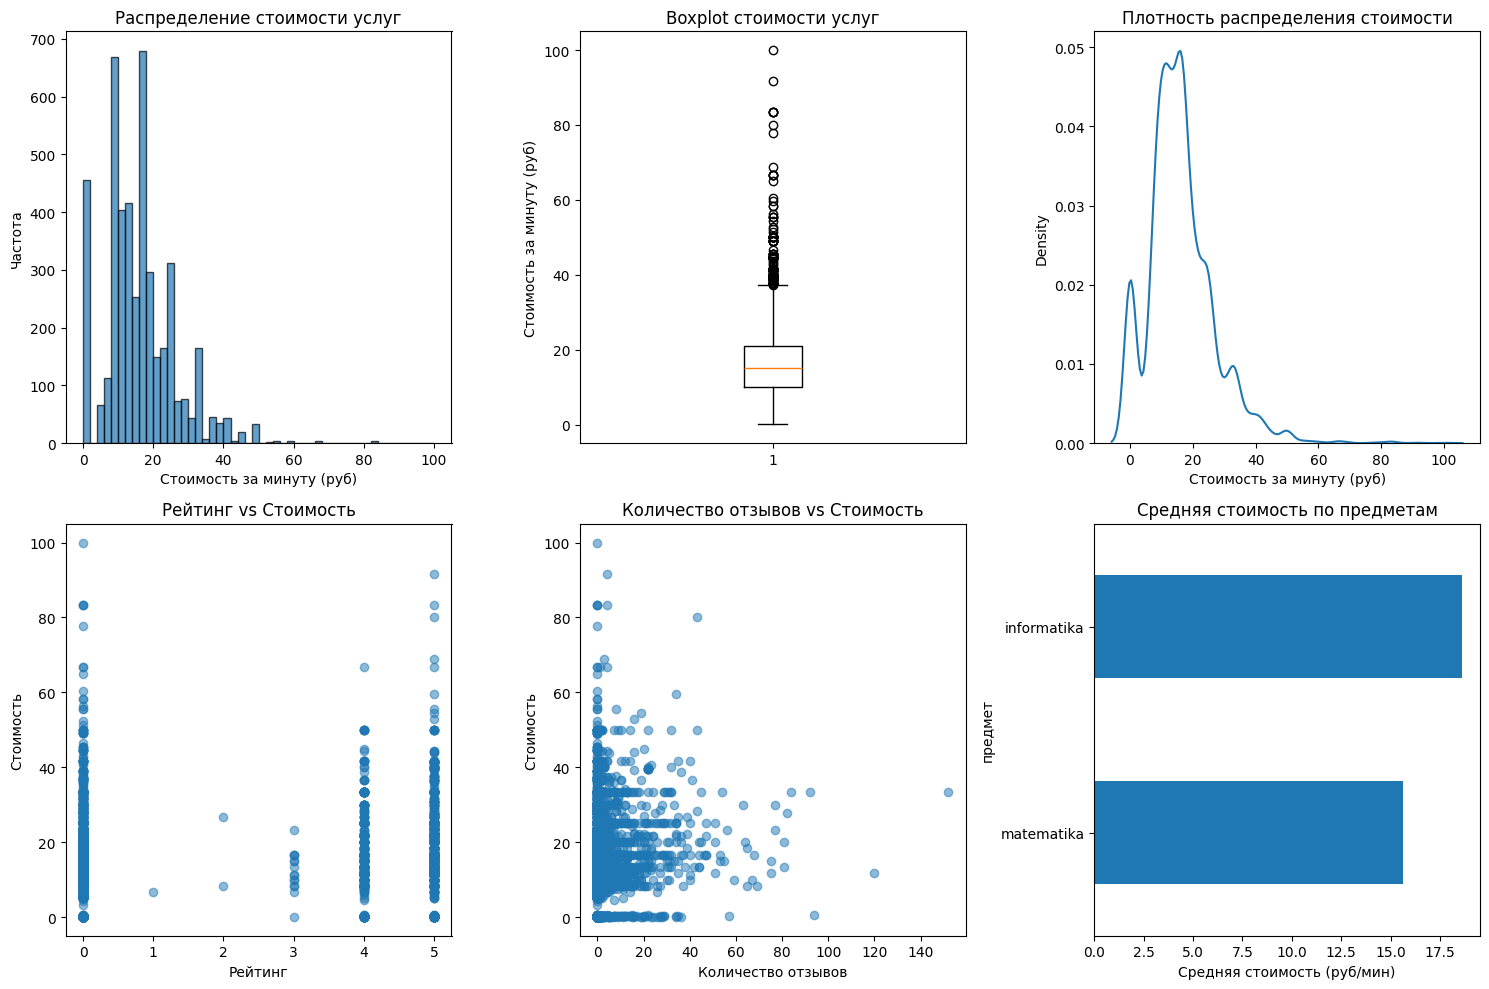


4. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:
                  Пропущенных значений  Процент пропусков
Education_6                       4547          99.978012
Ученое звание 2                   4547          99.978012
Ученая степень 2                  4547          99.978012
Desc_Education_6                  4547          99.978012
Desc_Education_5                  4545          99.934037
Education_5                       4545          99.934037
Desc_Education_4                  4532          99.648197
Education_4                       4532          99.648197
Ученое звание 1                   4513          99.230431
Ученая степень 1                  4472          98.328936
Desc_Education_3                  4443          97.691293
Education_3                       4442          97.669305
Desc_Education_2                  3771          82.915567
Education_2                       3767          82.827617
experience_desc                   2377          52.264732
tutor_rating                       589 

In [4]:
def exploratory_data_analysis(df, target_col='mean_price'):
    """
    Детальный исследовательский анализ данных
    """
    print("="*80)
    print("ДЕТАЛЬНЫЙ АНАЛИЗ ДАННЫХ")
    print("="*80)
    
    # 1. Анализ целевой переменной
    print("\n1. АНАЛИЗ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ (mean_price):")
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 3, 1)
    plt.hist(df[target_col], bins=50, edgecolor='black', alpha=0.7)
    plt.title('Распределение стоимости услуг')
    plt.xlabel('Стоимость за минуту (руб)')
    plt.ylabel('Частота')
    
    plt.subplot(2, 3, 2)
    plt.boxplot(df[target_col])
    plt.title('Boxplot стоимости услуг')
    plt.ylabel('Стоимость за минуту (руб)')
    
    plt.subplot(2, 3, 3)
    sns.kdeplot(df[target_col])
    plt.title('Плотность распределения стоимости')
    plt.xlabel('Стоимость за минуту (руб)')
    
    # 2. Анализ числовых признаков
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if target_col in numeric_cols:
        numeric_cols.remove(target_col)
    
    print(f"\n2. ЧИСЛОВЫЕ ПРИЗНАКИ ({len(numeric_cols)}):")
    for col in numeric_cols[:5]:  # Показываем первые 5
        print(f"  {col}:")
        print(f"    Минимум: {df[col].min():.2f}")
        print(f"    Максимум: {df[col].max():.2f}")
        print(f"    Среднее: {df[col].mean():.2f}")
        print(f"    Медиана: {df[col].median():.2f}")
        print(f"    Пропуски: {df[col].isnull().sum()}")
    
    # Визуализация числовых признаков
    if len(numeric_cols) > 0:
        plt.subplot(2, 3, 4)
        if 'tutor_rating' in df.columns:
            plt.scatter(df['tutor_rating'], df[target_col], alpha=0.5)
            plt.title('Рейтинг vs Стоимость')
            plt.xlabel('Рейтинг')
            plt.ylabel('Стоимость')
        
        plt.subplot(2, 3, 5)
        if 'tutor_reviews' in df.columns:
            plt.scatter(df['tutor_reviews'], df[target_col], alpha=0.5)
            plt.title('Количество отзывов vs Стоимость')
            plt.xlabel('Количество отзывов')
            plt.ylabel('Стоимость')
    
    # 3. Анализ категориальных признаков
    categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    print(f"\n3. КАТЕГОРИАЛЬНЫЕ ПРИЗНАКИ ({len(categorical_cols)}):")
    for col in categorical_cols[:5]:  # Показываем первые 5
        print(f"  {col}:")
        print(f"    Уникальных значений: {df[col].nunique()}")
        print(f"    Топ-5 значений: {df[col].value_counts().head().to_dict()}")
        print(f"    Пропуски: {df[col].isnull().sum()}")
    
    # Визуализация категориальных признаков
    if len(categorical_cols) > 0:
        plt.subplot(2, 3, 6)
        if 'предмет' in df.columns:
            top_subjects = df['предмет'].value_counts().head(10).index
            df_top = df[df['предмет'].isin(top_subjects)]
            subject_prices = df_top.groupby('предмет')[target_col].mean().sort_values()
            subject_prices.plot(kind='barh')
            plt.title('Средняя стоимость по предметам')
            plt.xlabel('Средняя стоимость (руб/мин)')
    
    plt.tight_layout()
    plt.show()
    
    # 4. Анализ пропущенных значений
    print("\n4. АНАЛИЗ ПРОПУЩЕННЫХ ЗНАЧЕНИЙ:")
    missing_data = df.isnull().sum()
    missing_percent = (missing_data / len(df)) * 100
    
    missing_df = pd.DataFrame({
        'Пропущенных значений': missing_data,
        'Процент пропусков': missing_percent
    }).sort_values('Пропущенных значений', ascending=False)
    
    print(missing_df[missing_df['Пропущенных значений'] > 0])
    
    # 5. Корреляционный анализ
    print("\n5. КОРРЕЛЯЦИОННЫЙ АНАЛИЗ:")
    if len(numeric_cols) > 1:
        correlation_matrix = df[numeric_cols + [target_col]].corr()
        correlation_with_target = correlation_matrix[target_col].sort_values(ascending=False)
        
        print("\nКорреляция с целевой переменной:")
        for feature, corr in correlation_with_target.items():
            if feature != target_col:
                print(f"  {feature}: {corr:.3f}")
    
    return numeric_cols, categorical_cols

# Применяем EDA к тренировочным данным
numeric_cols, categorical_cols = exploratory_data_analysis(train_df)

In [5]:
def preprocess_data(train_df, test_df):
    """
    Комплексная предобработка данных
    """
    print("="*80)
    print("ПРЕДОБРАБОТКА ДАННЫХ")
    print("="*80)
    
    # Сохраняем id для тестовых данных
    test_ids = test_df['id'] if 'id' in test_df.columns else None
    
    # Разделяем признаки и целевую переменную
    X_train = train_df.drop('mean_price', axis=1)
    y_train = train_df['mean_price']
    
    X_test = test_df.copy()
    
    # Сохраняем информацию о колонках
    original_cols_train = X_train.columns.tolist()
    original_cols_test = X_test.columns.tolist()
    
    print(f"\nОригинальные признаки в train: {len(original_cols_train)}")
    print(f"Оригинальные признаки в test: {len(original_cols_test)}")
    
    # 1. Обработка текстовых полей
    print("\n1. ОБРАБОТКА ТЕКСТОВЫХ ПОЛЕЙ:")
    
    text_columns = ['ФИО', 'description', 'experience_desc']
    
    for col in text_columns:
        if col in X_train.columns:
            print(f"  Обработка {col}:")
            
            # Заполнение пропусков
            X_train[col] = X_train[col].fillna('')
            if col in X_test.columns:
                X_test[col] = X_test[col].fillna('')
            
            # Извлечение признаков из текста
            X_train[f'{col}_length'] = X_train[col].apply(len)
            if col in X_test.columns:
                X_test[f'{col}_length'] = X_test[col].apply(len)
            
            # Подсчет количества слов
            X_train[f'{col}_word_count'] = X_train[col].apply(lambda x: len(str(x).split()))
            if col in X_test.columns:
                X_test[f'{col}_word_count'] = X_test[col].apply(lambda x: len(str(x).split()))
            
            print(f"    Добавлены признаки: {col}_length, {col}_word_count")
    
    # 2. Обработка категориальных признаков
    print("\n2. ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:")
    
    # Определяем категориальные колонки после добавления новых признаков
    cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
    
    for col in cat_cols:
        print(f"  Обработка {col}:")
        
        # Заполнение пропусков
        X_train[col] = X_train[col].fillna('Не указано')
        if col in X_test.columns:
            X_test[col] = X_test[col].fillna('Не указано')
        
        # Для признаков с небольшим количеством уникальных значений используем OneHot
        if X_train[col].nunique() <= 20:
            print(f"    OneHot кодирование для {col} ({X_train[col].nunique()} уникальных значений)")
            
            # OneHot кодирование
            ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
            encoded_train = ohe.fit_transform(X_train[[col]])
            encoded_test = ohe.transform(X_test[[col]]) if col in X_test.columns else None
            
            # Создаем датафреймы с закодированными признаками
            encoded_cols = [f"{col}_{val}" for val in ohe.categories_[0]]
            encoded_train_df = pd.DataFrame(encoded_train, columns=encoded_cols, index=X_train.index)
            
            if encoded_test is not None:
                encoded_test_df = pd.DataFrame(encoded_test, columns=encoded_cols, index=X_test.index)
            
            # Удаляем оригинальную колонку и добавляем закодированные
            X_train = X_train.drop(col, axis=1)
            X_train = pd.concat([X_train, encoded_train_df], axis=1)
            
            if col in X_test.columns:
                X_test = X_test.drop(col, axis=1)
                if encoded_test is not None:
                    X_test = pd.concat([X_test, encoded_test_df], axis=1)
        
        # Для признаков со многими уникальными значениями используем Target Encoding
        else:
            print(f"    Target кодирование для {col} ({X_train[col].nunique()} уникальных значений)")
            
            # Вычисляем среднюю цену для каждого значения
            target_encoding = train_df.groupby(col)['mean_price'].mean().to_dict()
            
            # Применяем кодирование
            X_train[f'{col}_encoded'] = X_train[col].map(target_encoding).fillna(y_train.mean())
            if col in X_test.columns:
                X_test[f'{col}_encoded'] = X_test[col].map(target_encoding).fillna(y_train.mean())
            
            # Удаляем оригинальную колонку
            X_train = X_train.drop(col, axis=1)
            if col in X_test.columns:
                X_test = X_test.drop(col, axis=1)
    
    # 3. Обработка числовых признаков
    print("\n3. ОБРАБОТКА ЧИСЛОВЫХ ПРИЗНАКОВ:")
    
    numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    
    for col in numeric_cols:
        print(f"  Обработка {col}:")
        
        # Заполнение пропусков медианой
        median_val = X_train[col].median()
        X_train[col] = X_train[col].fillna(median_val)
        
        if col in X_test.columns:
            X_test[col] = X_test[col].fillna(median_val)
        
        # Обработка выбросов (только в тренировочных данных)
        Q1 = X_train[col].quantile(0.25)
        Q3 = X_train[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 3 * IQR
        upper_bound = Q3 + 3 * IQR
        
        # Winsorizing: заменяем выбросы граничными значениями
        X_train[col] = X_train[col].clip(lower_bound, upper_bound)
    
    # 4. Удаление ненужных колонок
    print("\n4. УДАЛЕНИЕ НЕНУЖНЫХ КОЛОНОК:")
    
    # Удаляем константные колонки
    cols_to_drop = []
    for col in X_train.columns:
        if X_train[col].nunique() <= 1:
            cols_to_drop.append(col)
    
    if cols_to_drop:
        print(f"  Удалены константные колонки: {cols_to_drop}")
        X_train = X_train.drop(cols_to_drop, axis=1)
        X_test = X_test.drop(cols_to_drop, axis=1, errors='ignore')
    
    # 5. Проверка согласованности колонок
    print("\n5. ПРОВЕРКА СОГЛАСОВАННОСТИ КОЛОНОК:")
    
    # Убедимся, что в train и test одинаковые колонки
    train_cols = set(X_train.columns)
    test_cols = set(X_test.columns)
    
    missing_in_test = train_cols - test_cols
    missing_in_train = test_cols - train_cols
    
    if missing_in_test:
        print(f"  Добавляем в test отсутствующие колонки: {missing_in_test}")
        for col in missing_in_test:
            X_test[col] = 0
    
    if missing_in_train:
        print(f"  Добавляем в train отсутствующие колонки: {missing_in_train}")
        for col in missing_in_train:
            X_train[col] = 0
    
    # Упорядочиваем колонки одинаково
    common_cols = list(train_cols.intersection(test_cols))
    X_train = X_train[common_cols]
    X_test = X_test[common_cols]
    
    print(f"\nИтоговая размерность:")
    print(f"  X_train: {X_train.shape}")
    print(f"  X_test: {X_test.shape}")
    
    return X_train, y_train, X_test, test_ids

# Применяем предобработку
X_train_processed, y_train_processed, X_test_processed, test_ids = preprocess_data(train_df, test_df)

ПРЕДОБРАБОТКА ДАННЫХ

Оригинальные признаки в train: 27
Оригинальные признаки в test: 27

1. ОБРАБОТКА ТЕКСТОВЫХ ПОЛЕЙ:
  Обработка ФИО:
    Добавлены признаки: ФИО_length, ФИО_word_count
  Обработка description:
    Добавлены признаки: description_length, description_word_count
  Обработка experience_desc:
    Добавлены признаки: experience_desc_length, experience_desc_word_count

2. ОБРАБОТКА КАТЕГОРИАЛЬНЫХ ПРИЗНАКОВ:
  Обработка предмет:
    OneHot кодирование для предмет (2 уникальных значений)
  Обработка ФИО:
    Target кодирование для ФИО (3817 уникальных значений)
  Обработка tutor_head_tags:
    Target кодирование для tutor_head_tags (353 уникальных значений)
  Обработка description:
    Target кодирование для description (2766 уникальных значений)
  Обработка experience_desc:
    Target кодирование для experience_desc (840 уникальных значений)
  Обработка Education_1:
    Target кодирование для Education_1 (1312 уникальных значений)
  Обработка Desc_Education_1:
    Target ко

FEATURE ENGINEERING И ОТБОР ПРИЗНАКОВ

1. СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ:
  Добавлен признак: rating_reviews_interaction
  Добавлен признак: rating_squared
  Добавлен признак: reviews_binned

2. ОТБОР ПРИЗНАКОВ:


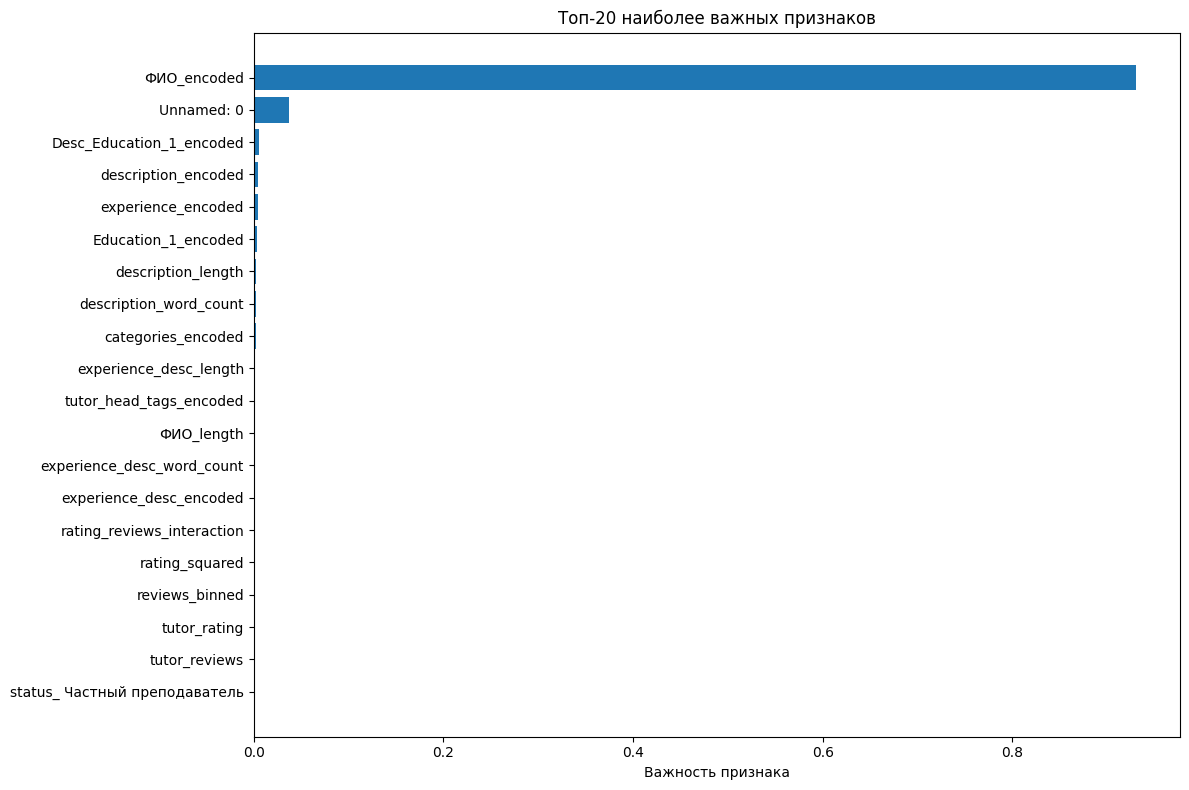


  Всего признаков: 21
  Отобрано признаков: 5
  Порог важности: 0.0037

  Топ-10 важных признаков:
    1. ФИО_encoded: 0.9302
    2. Unnamed: 0: 0.0373
    3. Desc_Education_1_encoded: 0.0052
    4. description_encoded: 0.0042
    5. experience_encoded: 0.0041
    6. Education_1_encoded: 0.0037
    7. description_length: 0.0024
    8. description_word_count: 0.0022
    9. categories_encoded: 0.0020
    10. experience_desc_length: 0.0017

3. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ:
  Масштабирование завершено
  Размерность после отбора: (4548, 5)


In [6]:
def feature_engineering_and_selection(X_train, y_train, X_test):
    """
    Feature Engineering и отбор наиболее важных признаков
    """
    print("="*80)
    print("FEATURE ENGINEERING И ОТБОР ПРИЗНАКОВ")
    print("="*80)
    
    # 1. Создание новых признаков
    print("\n1. СОЗДАНИЕ НОВЫХ ПРИЗНАКОВ:")
    
    # Копируем данные
    X_train_fe = X_train.copy()
    X_test_fe = X_test.copy()
    
    # Взаимодействия между признаками
    if 'tutor_rating' in X_train_fe.columns and 'tutor_reviews' in X_train_fe.columns:
        X_train_fe['rating_reviews_interaction'] = X_train_fe['tutor_rating'] * X_train_fe['tutor_reviews']
        X_test_fe['rating_reviews_interaction'] = X_test_fe['tutor_rating'] * X_test_fe['tutor_reviews']
        print("  Добавлен признак: rating_reviews_interaction")
    
    # Признаки на основе статистики
    if 'tutor_rating' in X_train_fe.columns:
        X_train_fe['rating_squared'] = X_train_fe['tutor_rating'] ** 2
        X_test_fe['rating_squared'] = X_test_fe['tutor_rating'] ** 2
        print("  Добавлен признак: rating_squared")
    
    # Биннинг числовых признаков
    if 'tutor_reviews' in X_train_fe.columns:
        X_train_fe['reviews_binned'] = pd.cut(X_train_fe['tutor_reviews'], 
                                             bins=5, 
                                             labels=False)
        X_test_fe['reviews_binned'] = pd.cut(X_test_fe['tutor_reviews'],
                                            bins=5,
                                            labels=False)
        print("  Добавлен признак: reviews_binned")
    
    # 2. Отбор признаков
    print("\n2. ОТБОР ПРИЗНАКОВ:")
    
    # Используем RandomForest для оценки важности признаков
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train_fe, y_train)
    
    # Получаем важность признаков
    feature_importance = pd.DataFrame({
        'feature': X_train_fe.columns,
        'importance': rf.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Визуализация важности признаков
    plt.figure(figsize=(12, 8))
    top_n = min(20, len(feature_importance))
    top_features = feature_importance.head(top_n)
    
    plt.barh(range(len(top_features)), top_features['importance'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Важность признака')
    plt.title(f'Топ-{top_n} наиболее важных признаков')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Выбираем наиболее важные признаки
    importance_threshold = feature_importance['importance'].quantile(0.75)
    selected_features = feature_importance[feature_importance['importance'] > importance_threshold]['feature'].tolist()
    
    print(f"\n  Всего признаков: {len(feature_importance)}")
    print(f"  Отобрано признаков: {len(selected_features)}")
    print(f"  Порог важности: {importance_threshold:.4f}")
    print(f"\n  Топ-10 важных признаков:")
    for i, (feature, importance) in enumerate(feature_importance.head(10).values, 1):
        print(f"    {i}. {feature}: {importance:.4f}")
    
    # 3. Масштабирование признаков
    print("\n3. МАСШТАБИРОВАНИЕ ПРИЗНАКОВ:")
    
    scaler = StandardScaler()
    X_train_selected = X_train_fe[selected_features]
    X_test_selected = X_test_fe[selected_features]
    
    X_train_scaled = scaler.fit_transform(X_train_selected)
    X_test_scaled = scaler.transform(X_test_selected)
    
    print(f"  Масштабирование завершено")
    print(f"  Размерность после отбора: {X_train_scaled.shape}")
    
    return X_train_scaled, X_test_scaled, selected_features, scaler, feature_importance

# Применяем Feature Engineering и отбор признаков
X_train_final, X_test_final, selected_features, scaler, feature_importance = \
    feature_engineering_and_selection(X_train_processed, y_train_processed, X_test_processed)

ОБУЧЕНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ

МОДЕЛЬ: Linear Regression
Тренировочная выборка:
  MSE:  8.5805
  RMSE: 2.9293
  MAE:  0.8066
  R²:   0.9205

Валидационная выборка:
  MSE:  13.5054
  RMSE: 3.6750
  MAE:  0.9226
  R²:   0.8855

Кросс-валидация (5-fold):
  MSE:  9.6487 ± 1.5174

МОДЕЛЬ: Ridge Regression
Тренировочная выборка:
  MSE:  8.5808
  RMSE: 2.9293
  MAE:  0.8040
  R²:   0.9205

Валидационная выборка:
  MSE:  13.5063
  RMSE: 3.6751
  MAE:  0.9193
  R²:   0.8855

Кросс-валидация (5-fold):
  MSE:  9.6492 ± 1.5214

МОДЕЛЬ: Lasso Regression
Тренировочная выборка:
  MSE:  8.6009
  RMSE: 2.9327
  MAE:  0.7433
  R²:   0.9203

Валидационная выборка:
  MSE:  13.5931
  RMSE: 3.6869
  MAE:  0.8562
  R²:   0.8848

Кросс-валидация (5-fold):
  MSE:  9.6546 ± 1.5501

МОДЕЛЬ: ElasticNet
Тренировочная выборка:
  MSE:  9.3581
  RMSE: 3.0591
  MAE:  0.9922
  R²:   0.9133

Валидационная выборка:
  MSE:  14.3933
  RMSE: 3.7938
  MAE:  1.1151
  R²:   0.8780

Кросс-валидация (5-fold):
  MSE:  10.4178 ± 1.

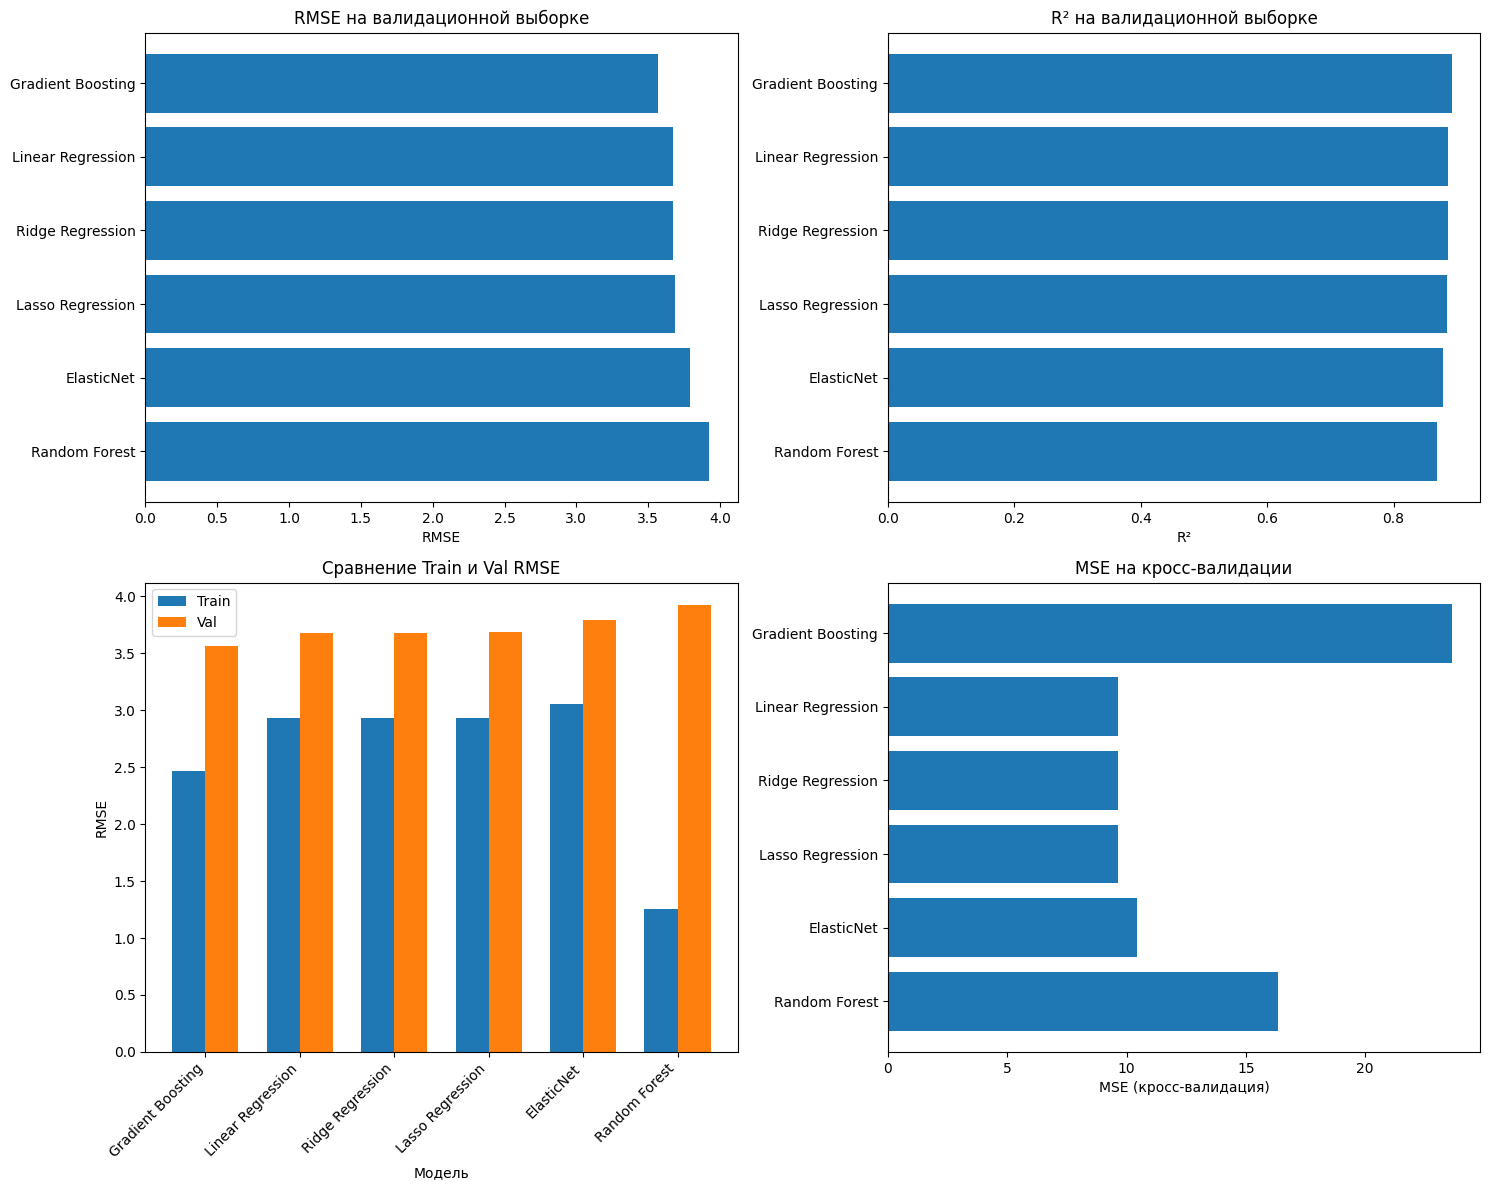


ЛУЧШАЯ МОДЕЛЬ: Gradient Boosting
RMSE на валидации: 3.5681
R² на валидации: 0.8921


In [7]:
def train_and_compare_models(X_train, y_train, cv_folds=5):
    """
    Обучение и сравнение различных моделей регрессии
    """
    print("="*80)
    print("ОБУЧЕНИЕ И СРАВНЕНИЕ МОДЕЛЕЙ")
    print("="*80)
    
    # Разделение на тренировочную и валидационную выборки
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_train, y_train, test_size=0.2, random_state=42
    )
    
    # Определяем модели для сравнения
    models = {
        'Linear Regression': LinearRegression(),
        'Ridge Regression': Ridge(alpha=1.0, random_state=42),
        'Lasso Regression': Lasso(alpha=0.1, random_state=42),
        'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
    }
    
    results = {}
    
    for name, model in models.items():
        print(f"\n{'='*60}")
        print(f"МОДЕЛЬ: {name}")
        print(f"{'='*60}")
        
        # Обучение модели
        model.fit(X_train_split, y_train_split)
        
        # Предсказания
        y_train_pred = model.predict(X_train_split)
        y_val_pred = model.predict(X_val_split)
        
        # Метрики на тренировочной выборке
        train_mse = mean_squared_error(y_train_split, y_train_pred)
        train_rmse = np.sqrt(train_mse)
        train_mae = mean_absolute_error(y_train_split, y_train_pred)
        train_r2 = r2_score(y_train_split, y_train_pred)
        
        # Метрики на валидационной выборке
        val_mse = mean_squared_error(y_val_split, y_val_pred)
        val_rmse = np.sqrt(val_mse)
        val_mae = mean_absolute_error(y_val_split, y_val_pred)
        val_r2 = r2_score(y_val_split, y_val_pred)
        
        # Кросс-валидация
        cv_scores = cross_val_score(model, X_train, y_train, 
                                   cv=cv_folds, 
                                   scoring='neg_mean_squared_error')
        cv_mse = -cv_scores.mean()
        cv_std = cv_scores.std()
        
        # Сохраняем результаты
        results[name] = {
            'model': model,
            'train_mse': train_mse,
            'train_rmse': train_rmse,
            'train_mae': train_mae,
            'train_r2': train_r2,
            'val_mse': val_mse,
            'val_rmse': val_rmse,
            'val_mae': val_mae,
            'val_r2': val_r2,
            'cv_mse': cv_mse,
            'cv_std': cv_std
        }
        
        # Вывод результатов
        print(f"Тренировочная выборка:")
        print(f"  MSE:  {train_mse:.4f}")
        print(f"  RMSE: {train_rmse:.4f}")
        print(f"  MAE:  {train_mae:.4f}")
        print(f"  R²:   {train_r2:.4f}")
        
        print(f"\nВалидационная выборка:")
        print(f"  MSE:  {val_mse:.4f}")
        print(f"  RMSE: {val_rmse:.4f}")
        print(f"  MAE:  {val_mae:.4f}")
        print(f"  R²:   {val_r2:.4f}")
        
        print(f"\nКросс-валидация ({cv_folds}-fold):")
        print(f"  MSE:  {cv_mse:.4f} ± {cv_std:.4f}")
    
    # Сравнение моделей
    print(f"\n{'='*80}")
    print("СРАВНЕНИЕ МОДЕЛЕЙ")
    print(f"{'='*80}")
    
    comparison_df = pd.DataFrame({
        'Model': list(results.keys()),
        'Train_RMSE': [results[m]['train_rmse'] for m in results],
        'Val_RMSE': [results[m]['val_rmse'] for m in results],
        'Val_R²': [results[m]['val_r2'] for m in results],
        'CV_MSE': [results[m]['cv_mse'] for m in results]
    }).sort_values('Val_RMSE')
    
    print("\nСравнение по RMSE на валидационной выборке:")
    print(comparison_df[['Model', 'Val_RMSE', 'Val_R²']].to_string(index=False))
    
    # Визуализация сравнения
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # График 1: RMSE на валидации
    axes[0, 0].barh(comparison_df['Model'], comparison_df['Val_RMSE'])
    axes[0, 0].set_xlabel('RMSE')
    axes[0, 0].set_title('RMSE на валидационной выборке')
    axes[0, 0].invert_yaxis()
    
    # График 2: R² на валидации
    axes[0, 1].barh(comparison_df['Model'], comparison_df['Val_R²'])
    axes[0, 1].set_xlabel('R²')
    axes[0, 1].set_title('R² на валидационной выборке')
    axes[0, 1].axvline(x=0, color='r', linestyle='--')
    axes[0, 1].invert_yaxis()
    
    # График 3: Сравнение Train и Val RMSE
    x = np.arange(len(comparison_df))
    width = 0.35
    axes[1, 0].bar(x - width/2, comparison_df['Train_RMSE'], width, label='Train')
    axes[1, 0].bar(x + width/2, comparison_df['Val_RMSE'], width, label='Val')
    axes[1, 0].set_xlabel('Модель')
    axes[1, 0].set_ylabel('RMSE')
    axes[1, 0].set_title('Сравнение Train и Val RMSE')
    axes[1, 0].set_xticks(x)
    axes[1, 0].set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    axes[1, 0].legend()
    
    # График 4: MSE на кросс-валидации
    axes[1, 1].barh(comparison_df['Model'], comparison_df['CV_MSE'])
    axes[1, 1].set_xlabel('MSE (кросс-валидация)')
    axes[1, 1].set_title('MSE на кросс-валидации')
    axes[1, 1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # Определяем лучшую модель
    best_model_name = comparison_df.iloc[0]['Model']
    best_model = results[best_model_name]['model']
    
    print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
    print(f"RMSE на валидации: {comparison_df.iloc[0]['Val_RMSE']:.4f}")
    print(f"R² на валидации: {comparison_df.iloc[0]['Val_R²']:.4f}")
    
    return results, comparison_df, best_model_name, best_model

# Обучение и сравнение моделей
results, comparison_df, best_model_name, best_model = train_and_compare_models(
    X_train_final, y_train_processed, cv_folds=5
)

In [8]:
def hyperparameter_tuning(X_train, y_train, model_name, base_model, param_grid):
    """
    Подбор гиперпараметров с помощью GridSearchCV
    """
    print("="*80)
    print(f"ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ {model_name}")
    print("="*80)
    
    # Используем KFold для кросс-валидации
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # Настройка GridSearchCV
    grid_search = GridSearchCV(
        estimator=base_model,
        param_grid=param_grid,
        cv=kf,
        scoring='neg_mean_squared_error',
        n_jobs=-1,
        verbose=1
    )
    
    print(f"Начинаем подбор гиперпараметров...")
    print(f"Параметры для перебора: {param_grid}")
    
    # Запуск GridSearch
    grid_search.fit(X_train, y_train)
    
    # Результаты
    print(f"\nРЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ:")
    print(f"Лучшие параметры: {grid_search.best_params_}")
    print(f"Лучший MSE: {-grid_search.best_score_:.4f}")
    print(f"Лучший RMSE: {np.sqrt(-grid_search.best_score_):.4f}")
    
    # Результаты для всех комбинаций
    print(f"\nТоп-5 комбинаций параметров:")
    results_df = pd.DataFrame(grid_search.cv_results_)
    top_results = results_df.sort_values('mean_test_score', ascending=False).head()
    
    for i, (_, row) in enumerate(top_results.iterrows(), 1):
        params = {k: v for k, v in row['params'].items()}
        score = -row['mean_test_score']
        print(f"{i}. Параметры: {params}")
        print(f"   MSE: {score:.4f}, RMSE: {np.sqrt(score):.4f}")
    
    return grid_search.best_estimator_, grid_search.best_params_

# Подбор гиперпараметров в зависимости от лучшей модели
print(f"\nПодбор гиперпараметров для модели: {best_model_name}")

if best_model_name == 'Ridge Regression':
    param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000],
        'solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga']
    }
    base_model = Ridge(random_state=42)
    
elif best_model_name == 'Lasso Regression':
    param_grid = {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
        'max_iter': [1000, 5000, 10000]
    }
    base_model = Lasso(random_state=42)
    
elif best_model_name == 'ElasticNet':
    param_grid = {
        'alpha': [0.0001, 0.001, 0.01, 0.1, 1],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9],
        'max_iter': [1000, 5000]
    }
    base_model = ElasticNet(random_state=42)
    
elif best_model_name == 'Random Forest':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4]
    }
    base_model = RandomForestRegressor(random_state=42)
    
elif best_model_name == 'Gradient Boosting':
    param_grid = {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'max_depth': [3, 5, 7],
        'min_samples_split': [2, 5, 10]
    }
    base_model = GradientBoostingRegressor(random_state=42)
    
else:  # Linear Regression
    print("Для Linear Regression нет гиперпараметров для настройки")
    tuned_model = best_model
    best_params = {}

if best_model_name != 'Linear Regression':
    tuned_model, best_params = hyperparameter_tuning(
        X_train_final, y_train_processed, best_model_name, base_model, param_grid
    )
else:
    tuned_model = best_model
    best_params = {}


Подбор гиперпараметров для модели: Gradient Boosting
ПОДБОР ГИПЕРПАРАМЕТРОВ ДЛЯ Gradient Boosting
Начинаем подбор гиперпараметров...
Параметры для перебора: {'n_estimators': [50, 100, 200], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7], 'min_samples_split': [2, 5, 10]}
Fitting 5 folds for each of 108 candidates, totalling 540 fits

РЕЗУЛЬТАТЫ ПОДБОРА ГИПЕРПАРАМЕТРОВ:
Лучшие параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
Лучший MSE: 9.5587
Лучший RMSE: 3.0917

Топ-5 комбинаций параметров:
1. Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
   MSE: 9.5587, RMSE: 3.0917
2. Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 5, 'n_estimators': 100}
   MSE: 9.5702, RMSE: 3.0936
3. Параметры: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 10, 'n_estimators': 100}
   MSE: 9.5715, RMSE: 3.0938
4. Параметры: {'learning_rate': 0.1, 'max_depth': 3, '

ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ

МОДЕЛЬ: Gradient Boosting

Результаты на тренировочной выборке:
MSE:  7.6529
RMSE: 2.7664
MAE:  0.7016
R²:   0.9304


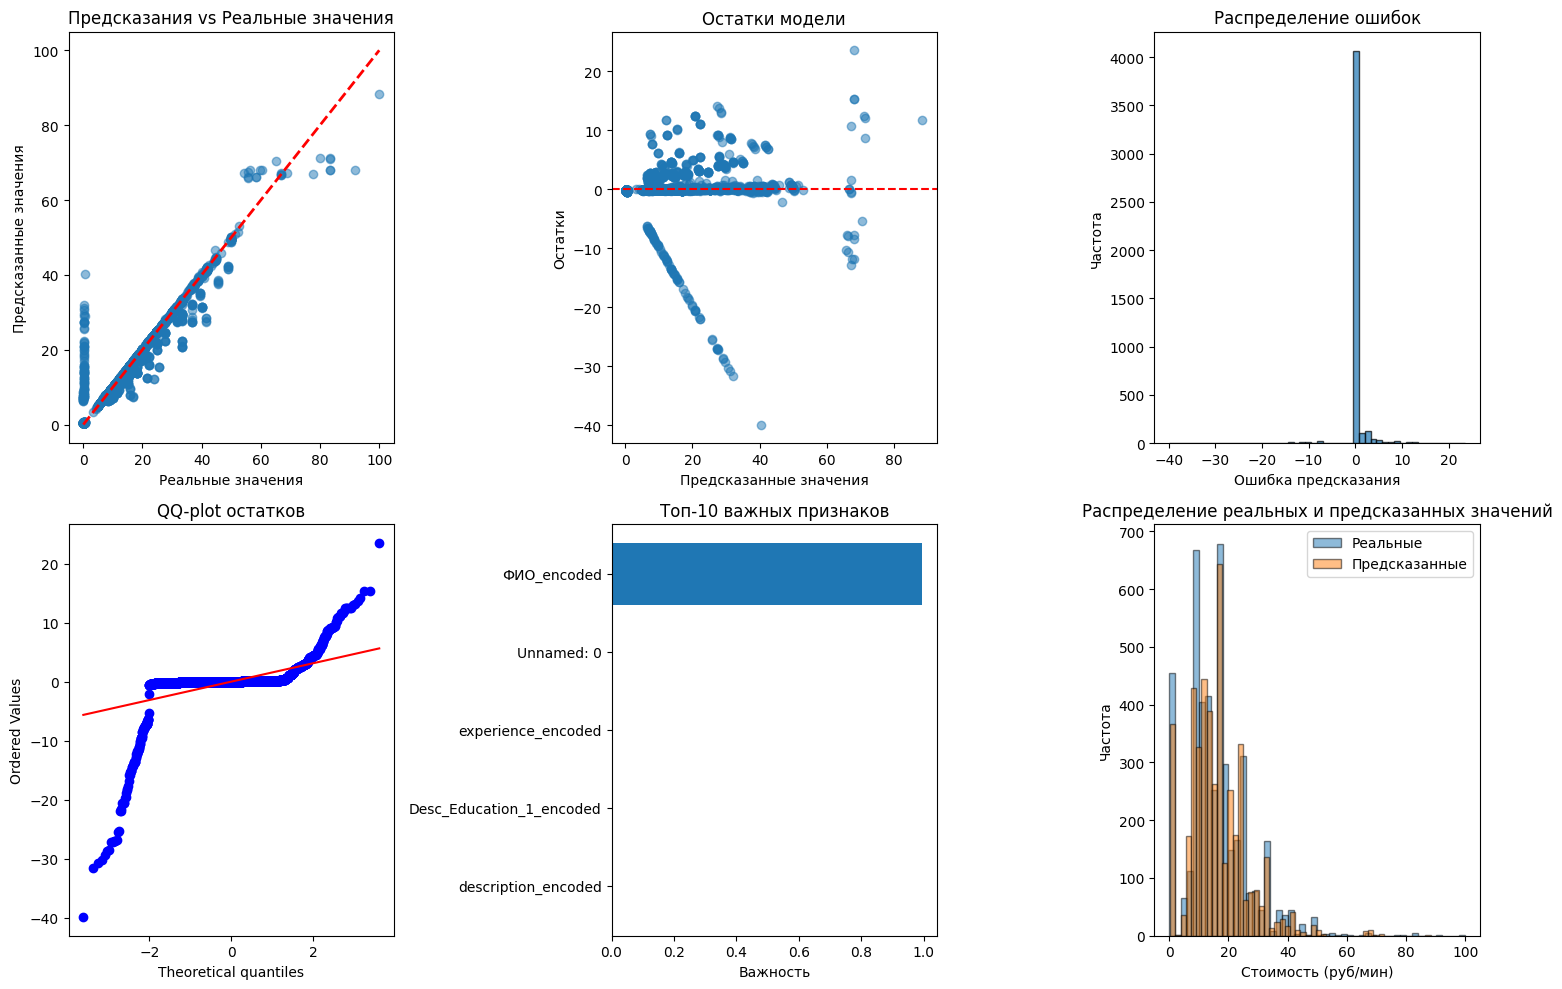


АНАЛИЗ БОЛЬШИХ ОШИБОК:
Самые большие ошибки:
          real  predicted      error  abs_error
3637  0.490741  40.343802 -39.853061  39.853061
3125  0.366667  31.966159 -31.599492  31.599492
997   0.400000  31.102260 -30.702260  30.702260
1150  0.400000  30.598968 -30.198968  30.198968
2863  0.333333  29.616842 -29.283509  29.283509
415   0.333333  29.027639 -28.694305  28.694305
669   0.454167  28.958371 -28.504204  28.504204
4357  0.315972  27.490871 -27.174899  27.174899
882   0.366667  27.484784 -27.118118  27.118118
3328  0.366667  27.414698 -27.048031  27.048031

Статистика ошибок:
Средняя абсолютная ошибка: 0.7016
Медианная абсолютная ошибка: 0.0593
Максимальная ошибка: 39.8531


In [9]:
def final_model_evaluation(model, X_train, y_train, X_test, feature_names, model_name):
    """
    Финальная оценка модели и анализ
    """
    print("="*80)
    print("ФИНАЛЬНАЯ ОЦЕНКА МОДЕЛИ")
    print("="*80)
    
    # Обучение на всех тренировочных данных
    model.fit(X_train, y_train)
    
    # Предсказания на тренировочных данных
    y_train_pred = model.predict(X_train)
    
    # Метрики
    train_mse = mean_squared_error(y_train, y_train_pred)
    train_rmse = np.sqrt(train_mse)
    train_mae = mean_absolute_error(y_train, y_train_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    
    print(f"\nМОДЕЛЬ: {model_name}")
    print(f"\nРезультаты на тренировочной выборке:")
    print(f"MSE:  {train_mse:.4f}")
    print(f"RMSE: {train_rmse:.4f}")
    print(f"MAE:  {train_mae:.4f}")
    print(f"R²:   {train_r2:.4f}")
    
    # Визуализация предсказаний
    plt.figure(figsize=(15, 10))
    
    # График 1: Предсказания vs Реальные значения
    plt.subplot(2, 3, 1)
    plt.scatter(y_train, y_train_pred, alpha=0.5)
    plt.plot([y_train.min(), y_train.max()], 
             [y_train.min(), y_train.max()], 
             'r--', lw=2)
    plt.xlabel('Реальные значения')
    plt.ylabel('Предсказанные значения')
    plt.title('Предсказания vs Реальные значения')
    
    # График 2: Остатки
    plt.subplot(2, 3, 2)
    residuals = y_train - y_train_pred
    plt.scatter(y_train_pred, residuals, alpha=0.5)
    plt.axhline(y=0, color='r', linestyle='--')
    plt.xlabel('Предсказанные значения')
    plt.ylabel('Остатки')
    plt.title('Остатки модели')
    
    # График 3: Распределение ошибок
    plt.subplot(2, 3, 3)
    plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Ошибка предсказания')
    plt.ylabel('Частота')
    plt.title('Распределение ошибок')
    
    # График 4: QQ-plot для проверки нормальности остатков
    plt.subplot(2, 3, 4)
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title('QQ-plot остатков')
    
    # График 5: Важность признаков (если доступно)
    if hasattr(model, 'feature_importances_'):
        plt.subplot(2, 3, 5)
        importance = pd.DataFrame({
            'feature': feature_names,
            'importance': model.feature_importances_
        }).sort_values('importance', ascending=False).head(10)
        
        plt.barh(range(len(importance)), importance['importance'])
        plt.yticks(range(len(importance)), importance['feature'])
        plt.xlabel('Важность')
        plt.title('Топ-10 важных признаков')
        plt.gca().invert_yaxis()
    
    # График 6: Распределение целевой переменной и предсказаний
    plt.subplot(2, 3, 6)
    plt.hist(y_train, bins=50, alpha=0.5, label='Реальные', edgecolor='black')
    plt.hist(y_train_pred, bins=50, alpha=0.5, label='Предсказанные', edgecolor='black')
    plt.xlabel('Стоимость (руб/мин)')
    plt.ylabel('Частота')
    plt.title('Распределение реальных и предсказанных значений')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Анализ больших ошибок
    print(f"\nАНАЛИЗ БОЛЬШИХ ОШИБОК:")
    error_df = pd.DataFrame({
        'real': y_train,
        'predicted': y_train_pred,
        'error': residuals,
        'abs_error': np.abs(residuals)
    }).sort_values('abs_error', ascending=False)
    
    print(f"Самые большие ошибки:")
    print(error_df.head(10))
    
    print(f"\nСтатистика ошибок:")
    print(f"Средняя абсолютная ошибка: {error_df['abs_error'].mean():.4f}")
    print(f"Медианная абсолютная ошибка: {error_df['abs_error'].median():.4f}")
    print(f"Максимальная ошибка: {error_df['abs_error'].max():.4f}")
    
    return model, y_train_pred, residuals

# Финальная оценка модели
final_model, y_train_pred, residuals = final_model_evaluation(
    tuned_model, X_train_final, y_train_processed, X_test_final,
    selected_features, best_model_name
)

ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ

Выполняем предсказания с помощью модели Gradient Boosting...

Статистика предсказаний:
Минимальное значение: 5.6771
Максимальное значение: 50.1323
Среднее значение: 16.4059
Медианное значение: 16.0915


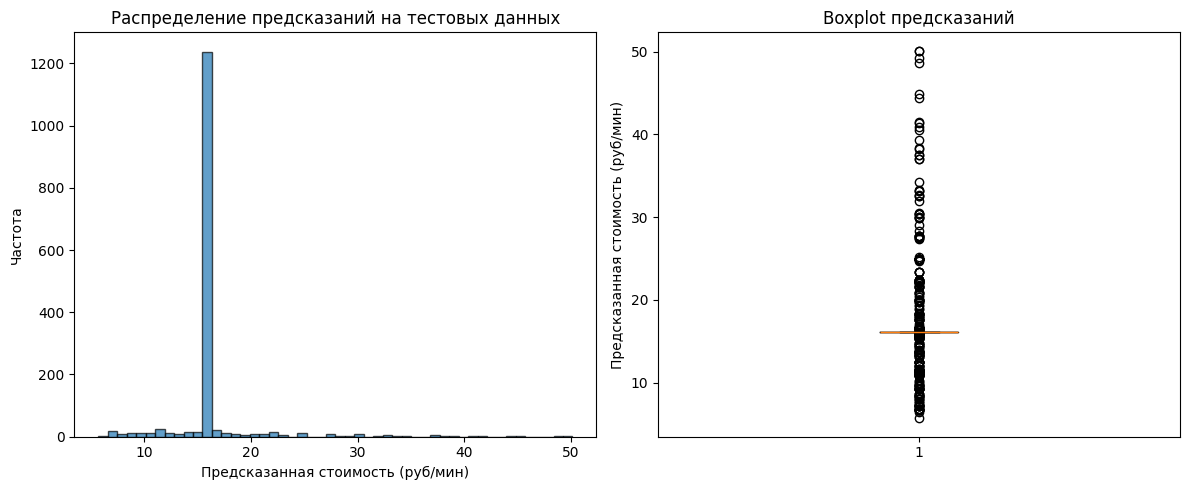


Проверка формата submission:
   id  mean_price
0   0   15.833448
1   1   15.833448
2   2   15.833448
3   3   15.833448
4   4    8.359872

Размер submission: (1516, 2)

Файл сохранен: submission.csv


In [10]:
def create_submission(model, X_test, test_ids, model_name):
    """
    Создание submission файла для Kaggle
    """
    print("="*80)
    print("ПРЕДСКАЗАНИЕ НА ТЕСТОВЫХ ДАННЫХ")
    print("="*80)
    
    # Предсказание на тестовых данных
    print(f"\nВыполняем предсказания с помощью модели {model_name}...")
    test_predictions = model.predict(X_test)
    
    # Проверка распределения предсказаний
    print(f"\nСтатистика предсказаний:")
    print(f"Минимальное значение: {test_predictions.min():.4f}")
    print(f"Максимальное значение: {test_predictions.max():.4f}")
    print(f"Среднее значение: {test_predictions.mean():.4f}")
    print(f"Медианное значение: {np.median(test_predictions):.4f}")
    
    # Визуализация распределения предсказаний
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.hist(test_predictions, bins=50, edgecolor='black', alpha=0.7)
    plt.xlabel('Предсказанная стоимость (руб/мин)')
    plt.ylabel('Частота')
    plt.title('Распределение предсказаний на тестовых данных')
    
    plt.subplot(1, 2, 2)
    plt.boxplot(test_predictions)
    plt.ylabel('Предсказанная стоимость (руб/мин)')
    plt.title('Boxplot предсказаний')
    
    plt.tight_layout()
    plt.show()
    
    # Создание submission файла
    if test_ids is not None:
        submission = pd.DataFrame({
            'id': test_ids,
            'mean_price': test_predictions
        })
    else:
        submission = pd.DataFrame({
            'id': range(len(test_predictions)),
            'mean_price': test_predictions
        })
    
    # Проверка формата
    print(f"\nПроверка формата submission:")
    print(submission.head())
    print(f"\nРазмер submission: {submission.shape}")
    
    # Сохранение файла
    submission_filename = 'submission.csv'
    submission.to_csv(submission_filename, index=False)
    print(f"\nФайл сохранен: {submission_filename}")
    
    return submission, test_predictions

# Создание submission файла
submission_df, test_predictions = create_submission(
    final_model, X_test_final, test_ids, best_model_name
)

## Kaggle

[Submittion - click here](https://github.com/PHILIPP111007/masters_degree_Roshchin_M25-555/blob/main/ML/tutors_lessons_prices/data/result.png)